# 02 — Make windows and 5 subject-wise folds

Этот ноутбук:

1. Читает `participant_data/participant_*/*.json`.
2. Использует один фиксированный сенсор `SENSOR_IDX = 0`.
3. Собирает плоский DataFrame с каналами `acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z`.
4. Нарезает окна `1 s`: `WINDOW_SIZE = 52`, `OVERLAP = 0.75`, `STRIDE = 13`.
5. Кодирует labels.
6. Создаёт `group_id`, где `participant_12` и `participant_12_2` считаются одной группой.
7. Создаёт 5 subject-wise folds через `GroupKFold`.
8. Нормализует каждый fold отдельно: `mean/std` считаются только по train текущего fold.
9. Сохраняет `fold0...fold4` в `data/processed`.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold

## 1. Config

In [2]:
RAW_DIR = Path("../participant_data").resolve()
OUT_DIR = Path("../data/processed").resolve()

SENSOR_IDX = 0
WINDOW_SIZE = 52
OVERLAP = 0.75
STRIDE = int(WINDOW_SIZE * (1.0 - OVERLAP))

CHANNELS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

assert RAW_DIR.exists(), f"RAW_DIR not found: {RAW_DIR}"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR)
print("OUT_DIR:", OUT_DIR)
print("SENSOR_IDX:", SENSOR_IDX)
print("WINDOW_SIZE:", WINDOW_SIZE)
print("OVERLAP:", OVERLAP)
print("STRIDE:", STRIDE)

RAW_DIR: /Users/arsenij/Desktop/kurs-ml-ssl/participant_data
OUT_DIR: /Users/arsenij/Desktop/kurs-ml-ssl/data/processed
SENSOR_IDX: 0
WINDOW_SIZE: 52
OVERLAP: 0.75
STRIDE: 13


## 2. Найти JSON файлы

In [3]:
json_files = sorted(RAW_DIR.glob("participant_*/*.json"))
participant_dirs = sorted([p for p in RAW_DIR.glob("participant_*") if p.is_dir()])

print("num json files:", len(json_files))
print("num participant dirs:", len(participant_dirs))
print("participants:", [p.name for p in participant_dirs])

print("\nfirst files:")
for p in json_files[:10]:
    print(" ", p.relative_to(RAW_DIR))

assert len(json_files) > 0

num json files: 147
num participant dirs: 21
participants: ['participant_1', 'participant_10', 'participant_11', 'participant_12', 'participant_12_2', 'participant_13', 'participant_14', 'participant_15', 'participant_16', 'participant_17', 'participant_18', 'participant_19', 'participant_2', 'participant_20', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9']

first files:
  participant_1/carioca_left_2020-07-21--19-35-00.json
  participant_1/carioca_right_2020-07-21--19-34-39.json
  participant_1/heel_to_butt_2020-07-21--19-35-51.json
  participant_1/high_knee_run_2020-07-21--19-35-23.json
  participant_1/running_2020-07-21--19-33-34.json
  participant_1/sideskips_left_2020-07-21--19-34-16.json
  participant_1/sideskips_right_2020-07-21--19-33-54.json
  participant_10/carioca_left_2020-08-27--20-28-30.json
  participant_10/carioca_right_2020-08-27--20-28-50.json
  participant_10/heel_to_butt_2020-08-27--20-31-54.json

## 3. Parser

In [4]:
def label_from_filename(path: Path) -> str:
    # Example:
    # carioca_left_2020-07-21--19-35-00.json -> carioca_left
    stem = path.stem
    return re.sub(r"_\d{4}-\d{2}-\d{2}--\d{2}-\d{2}-\d{2}$", "", stem)


def parse_one_json(path: Path, sensor_idx: int = 0) -> pd.DataFrame:
    path = Path(path)

    with open(path, "r") as f:
        obj = json.load(f)

    subject_id = path.parent.name
    label = obj.get("label", label_from_filename(path))

    datas = obj["datas"]
    sensor = datas[sensor_idx]

    acc = sensor["accData"]
    gyro = sensor["gyroData"]

    acc_ts = acc["timeStamp"]
    gyro_ts = gyro["timeStamp"]

    acc_x = acc["xAxisData"]
    acc_y = acc["yAxisData"]
    acc_z = acc["zAxisData"]

    gyro_x = gyro["xAxisData"]
    gyro_y = gyro["yAxisData"]
    gyro_z = gyro["zAxisData"]

    n = min(
        len(acc_ts), len(gyro_ts),
        len(acc_x), len(acc_y), len(acc_z),
        len(gyro_x), len(gyro_y), len(gyro_z),
    )

    df = pd.DataFrame({
        "timestamp": acc_ts[:n],
        "timestamp_acc": acc_ts[:n],
        "timestamp_gyro": gyro_ts[:n],
        "acc_x": acc_x[:n],
        "acc_y": acc_y[:n],
        "acc_z": acc_z[:n],
        "gyro_x": gyro_x[:n],
        "gyro_y": gyro_y[:n],
        "gyro_z": gyro_z[:n],
        "subject_id": subject_id,
        "label": label,
        "sensor_idx": sensor_idx,
        "deviceMac": sensor.get("deviceMac", None),
        "file": str(path.relative_to(RAW_DIR)),
    })

    return df


def load_all_json(json_files, sensor_idx: int = 0) -> pd.DataFrame:
    parts = []

    for path in json_files:
        df_one = parse_one_json(path, sensor_idx=sensor_idx)
        parts.append(df_one)

    return pd.concat(parts, ignore_index=True)

Были реализованы функции для извлечения label из имени файла, чтения одного JSON и загрузки всех JSON-файлов в общий DataFrame. Для каждого файла парсер берёт один выбранный сенсор `sensor_idx = 0` и собирает 6 каналов: `acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`. Также сохраняются `timestamp`, `subject_id`, `label`, `sensor_idx`, `deviceMac` и путь к файлу. Это превращает вложенную JSON-структуру в плоскую табличную форму, удобную для дальнейшей нарезки окон.

## 4. Parser проверка

In [5]:
sample_df = parse_one_json(json_files[0], sensor_idx=SENSOR_IDX)

print(sample_df.shape)
display(sample_df.head())
display(sample_df.describe())

(515, 14)


,timestamp,timestamp_acc,timestamp_gyro,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,subject_id,label,sensor_idx,deviceMac,file
0,1595352898619,1595352898619,1595352898619,6123,382,1993,1643,-1929,-3954,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
1,1595352898638,1595352898638,1595352898638,5536,-3662,2188,2279,-1079,-2370,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
2,1595352898657,1595352898657,1595352898657,4085,-3014,3580,4411,-776,140,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
3,1595352898676,1595352898676,1595352898676,3371,-1731,4555,2103,1037,2325,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
4,1595352898695,1595352898695,1595352898695,3715,-546,4925,1238,1658,3760,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...


,timestamp,timestamp_acc,timestamp_gyro,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,sensor_idx
count,5.150000e+02,5.150000e+02,5.150000e+02,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.0
mean,1.595353e+12,1.595353e+12,1.595353e+12,3514.143689,-777.407767,-1033.000000,44.328155,52.629126,31.633010,0.0
std,2.879721e+03,2.879721e+03,2.879721e+03,1670.821033,2198.443540,3549.997743,2667.034480,2194.494980,2870.437415,0.0
min,1.595353e+12,1.595353e+12,1.595353e+12,-1634.000000,-11030.000000,-7768.000000,-8147.000000,-4106.000000,-5558.000000,0.0
25%,1.595353e+12,1.595353e+12,1.595353e+12,2757.500000,-1690.000000,-4099.500000,-1198.500000,-1934.000000,-2188.500000,0.0
50%,1.595353e+12,1.595353e+12,1.595353e+12,3816.000000,-432.000000,-1068.000000,144.000000,-444.000000,-65.000000,0.0
75%,1.595353e+12,1.595353e+12,1.595353e+12,4682.500000,531.500000,2106.000000,1828.000000,2279.500000,2280.000000,0.0
max,1.595353e+12,1.595353e+12,1.595353e+12,7010.000000,4744.000000,6508.000000,5649.000000,4101.000000,6026.000000,0.0


Парсер был проверен на одном JSON-файле. Получился DataFrame с временными отсчётами выбранного сенсора и 6 IMU-каналами. Размер первой записи соответствует ожидаемой длине около 500 отсчётов. Это подтверждает, что данные акселерометра и гироскопа читаются корректно, а каналы можно объединять в один многоканальный временной ряд.

## 5. Загрузка всех файлов

In [6]:
df = load_all_json(json_files, sensor_idx=SENSOR_IDX)

print("df.shape:", df.shape)
display(df.head())

files_unique = df[["file", "subject_id", "label"]].drop_duplicates()

print("\nfiles_per_label:")
print(files_unique["label"].value_counts().sort_index())

print("\nfiles_per_subject:")
print(files_unique["subject_id"].value_counts().sort_index())

df.shape: (75103, 14)


,timestamp,timestamp_acc,timestamp_gyro,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,subject_id,label,sensor_idx,deviceMac,file
0,1595352898619,1595352898619,1595352898619,6123,382,1993,1643,-1929,-3954,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
1,1595352898638,1595352898638,1595352898638,5536,-3662,2188,2279,-1079,-2370,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
2,1595352898657,1595352898657,1595352898657,4085,-3014,3580,4411,-776,140,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
3,1595352898676,1595352898676,1595352898676,3371,-1731,4555,2103,1037,2325,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...
4,1595352898695,1595352898695,1595352898695,3715,-546,4925,1238,1658,3760,participant_1,carioca_left,0,D4:84:47:31:60:DA,participant_1/carioca_left_2020-07-21--19-35-0...



files_per_label:
label
carioca_left       21
carioca_right      21
heel_to_butt       21
high_knee_run      21
running            21
sideskips_left     21
sideskips_right    21
Name: count, dtype: int64

files_per_subject:
subject_id
participant_1       7
participant_10      7
participant_11      7
participant_12      7
participant_12_2    7
participant_13      7
participant_14      7
participant_15      7
participant_16      7
participant_17      7
participant_18      7
participant_19      7
participant_2       7
participant_20      7
participant_3       7
participant_4       7
participant_5       7
participant_6       7
participant_7       7
participant_8       7
participant_9       7
Name: count, dtype: int64


Все JSON-файлы были загружены в один общий DataFrame. В нём каждая строка соответствует одному timestep одного файла для выбранного `sensor_idx = 0`. Для каждого отсчёта сохранены значения акселерометра, гироскопа, timestamp, label, subject_id и имя исходного файла. Также проверено, что на уровне файлов каждый класс и каждый участник представлены ожидаемым количеством записей.

## 6. Data проверка

In [7]:
required_cols = CHANNELS + ["timestamp", "subject_id", "label", "file"]
missing_cols = [c for c in required_cols if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

print("missing values:")
print(df[required_cols].isna().sum())

df_sorted = df.sort_values(["file", "timestamp"]).copy()
df_sorted["timestamp_diff"] = df_sorted.groupby("file")["timestamp"].diff()

print("\ntimestamp diff describe:")
print(df_sorted["timestamp_diff"].dropna().describe())

print("\nchannel stats:")
display(df[CHANNELS].describe())

missing values:
acc_x         0
acc_y         0
acc_z         0
gyro_x        0
gyro_y        0
gyro_z        0
timestamp     0
subject_id    0
label         0
file          0
dtype: int64

timestamp diff describe:
count    74956.000000
mean        19.310609
std          0.975262
min         12.000000
25%         19.000000
50%         19.000000
75%         19.000000
max         26.000000
Name: timestamp_diff, dtype: float64

channel stats:


,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
count,75103.000000,75103.000000,75103.000000,75103.000000,75103.000000,75103.000000
mean,2656.529566,-34.948950,35.800061,1.917407,2.911042,-6.507037
std,2524.498280,2994.060912,2280.402614,2139.012252,1886.665820,3116.735202
min,-9141.000000,-17592.000000,-18944.000000,-18116.000000,-9993.000000,-12139.000000
25%,1002.000000,-1551.000000,-895.000000,-1042.000000,-1112.000000,-1567.000000
50%,2660.000000,-31.000000,107.000000,-15.000000,33.000000,-18.000000
75%,4155.000000,1590.000000,1249.000000,1063.000000,1101.000000,1537.000000
max,15579.000000,17046.000000,13266.000000,15508.000000,10496.000000,13544.000000


## 7. sliding windows

In [8]:
def make_windows(df: pd.DataFrame, window_size: int, stride: int):
    X = []
    y_raw = []
    subjects = []
    files = []
    starts = []

    group_cols = ["file", "subject_id", "label", "sensor_idx"]

    for _, g in df.groupby(group_cols):
        g = g.sort_values("timestamp")
        arr = g[CHANNELS].to_numpy(dtype=np.float32)  # [L, C]

        label = str(g["label"].iloc[0])
        subject_id = str(g["subject_id"].iloc[0])
        file_name = str(g["file"].iloc[0])

        if len(arr) < window_size:
            continue

        for start in range(0, len(arr) - window_size + 1, stride):
            end = start + window_size
            window = arr[start:end].T  # [C, T]

            X.append(window)
            y_raw.append(label)
            subjects.append(subject_id)
            files.append(file_name)
            starts.append(start)

    X = np.stack(X).astype(np.float32)
    y_raw = np.array(y_raw)
    subjects = np.array(subjects)
    files = np.array(files)
    starts = np.array(starts)

    return X, y_raw, subjects, files, starts


X, y_raw, subjects, files, starts = make_windows(
    df,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
)

print("X.shape:", X.shape)
print("y_raw.shape:", y_raw.shape)
print("subjects.shape:", subjects.shape)
print("files.shape:", files.shape)
print("starts.shape:", starts.shape)
print("X dtype:", X.dtype)

assert X.shape[1:] == (len(CHANNELS), WINDOW_SIZE)

X.shape: (5270, 6, 52)
y_raw.shape: (5270,)
subjects.shape: (5270,)
files.shape: (5270,)
starts.shape: (5270,)
X dtype: float32


Сырые временные ряды были нарезаны на окна фиксированной длины. Использовались параметры `WINDOW_SIZE = 52` и `STRIDE = 13`, что соответствует окнам примерно по 1 секунде с overlap 75%. После нарезки получился тензор `X` формы `(5270, 6, 52)`. Это означает, что сформировано 5270 окон, каждое окно содержит 6 каналов и 52 временных отсчёта. Такая форма подходит для обучения 1D-CNN в PyTorch в формате `[batch, channels, time]`.

## 8. Window metadata and balance

In [9]:
window_meta = pd.DataFrame({
    "label": y_raw,
    "subject_id": subjects,
    "file": files,
    "start": starts,
})

print("windows by label:")
print(window_meta["label"].value_counts().sort_index())

print("\nwindows by subject:")
print(window_meta["subject_id"].value_counts().sort_index())

print("\nwindows by subject and label:")
display(
    window_meta
    .groupby(["subject_id", "label"])
    .size()
    .unstack(fill_value=0)
)

windows by label:
label
carioca_left       759
carioca_right      759
heel_to_butt       723
high_knee_run      759
running            752
sideskips_left     759
sideskips_right    759
Name: count, dtype: int64

windows by subject:
subject_id
participant_1       252
participant_10      252
participant_11      252
participant_12      251
participant_12_2    252
participant_13      258
participant_14      259
participant_15      252
participant_16      252
participant_17      252
participant_18      252
participant_19      252
participant_2       252
participant_20      252
participant_3       252
participant_4       217
participant_5       253
participant_6       252
participant_7       252
participant_8       252
participant_9       252
Name: count, dtype: int64

windows by subject and label:


label,carioca_left,carioca_right,heel_to_butt,high_knee_run,running,sideskips_left,sideskips_right
subject_id,,,,,,,
participant_1,36,36,36,36,36,36,36
participant_10,36,36,36,36,36,36,36
participant_11,36,36,36,36,36,36,36
participant_12,36,36,35,36,36,36,36
participant_12_2,36,36,36,36,36,36,36
participant_13,37,37,36,37,37,37,37
participant_14,37,37,37,37,37,37,37
participant_15,36,36,36,36,36,36,36
participant_16,36,36,36,36,36,36,36


## 9. Визуализация

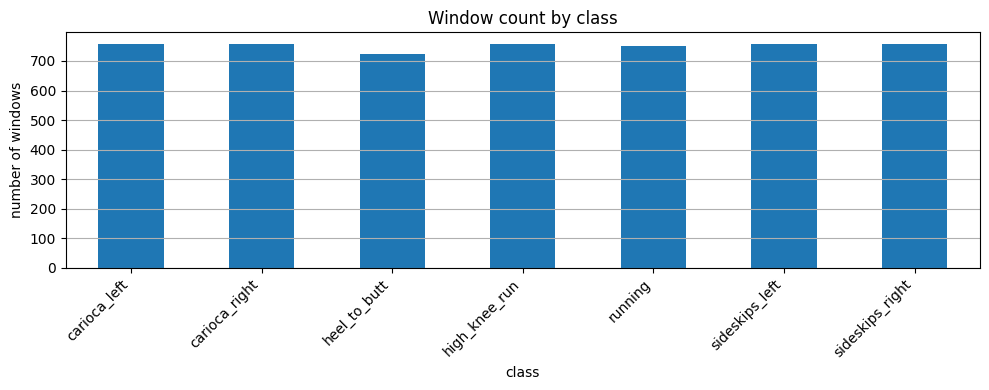

In [10]:
label_counts = pd.Series(y_raw).value_counts().sort_index()

plt.figure(figsize=(10, 4))
label_counts.plot(kind="bar")
plt.title("Window count by class")
plt.xlabel("class")
plt.ylabel("number of windows")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

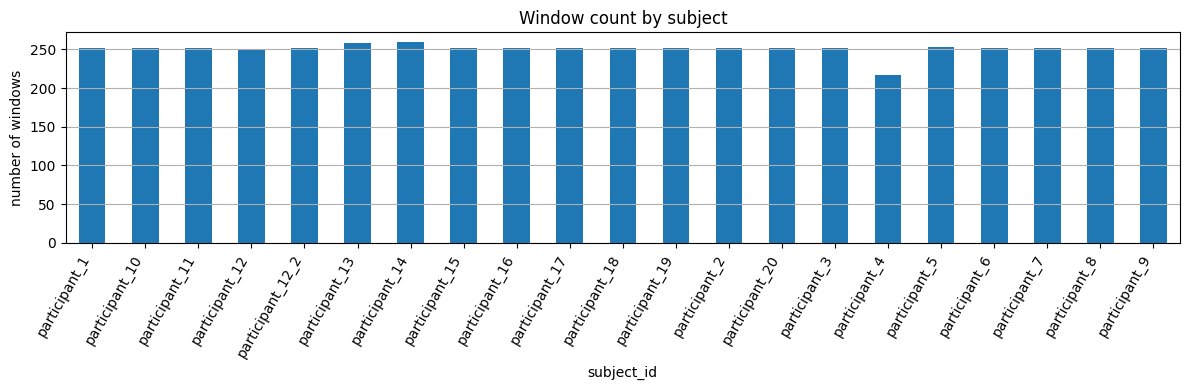

In [11]:
subject_counts = pd.Series(subjects).value_counts().sort_index()

plt.figure(figsize=(12, 4))
subject_counts.plot(kind="bar")
plt.title("Window count by subject")
plt.xlabel("subject_id")
plt.ylabel("number of windows")
plt.xticks(rotation=60, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

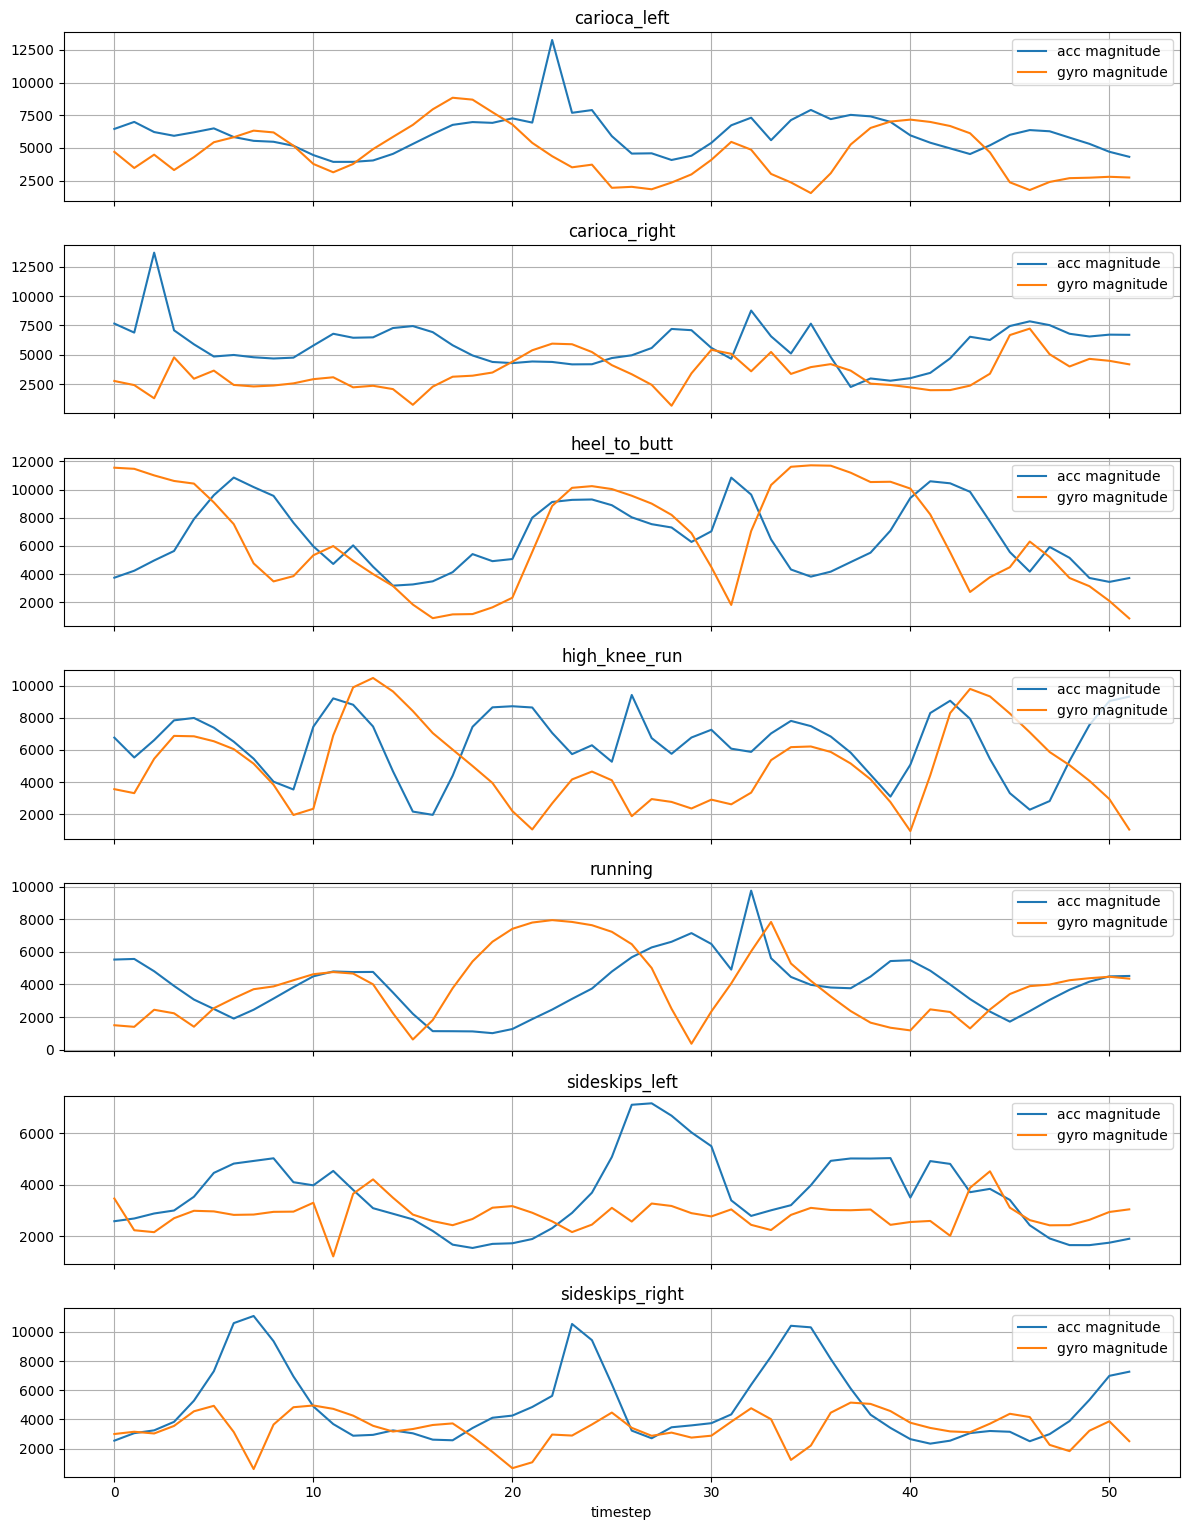

In [12]:
unique_labels = sorted(np.unique(y_raw))

fig, axes = plt.subplots(
    len(unique_labels),
    1,
    figsize=(12, 2.2 * len(unique_labels)),
    sharex=True,
)

for ax, label in zip(axes, unique_labels):
    idx = np.where(y_raw == label)[0][0]
    x = X[idx]  # [C, T]

    acc_mag = np.sqrt(x[0] ** 2 + x[1] ** 2 + x[2] ** 2)
    gyro_mag = np.sqrt(x[3] ** 2 + x[4] ** 2 + x[5] ** 2)

    ax.plot(acc_mag, label="acc magnitude")
    ax.plot(gyro_mag, label="gyro magnitude")
    ax.set_title(label)
    ax.grid(True)
    ax.legend(loc="upper right")

plt.xlabel("timestep")
plt.tight_layout()
plt.show()

## 10. Encode labels

In [13]:
labels_sorted = sorted(np.unique(y_raw))
label_to_id = {str(label): int(i) for i, label in enumerate(labels_sorted)}
id_to_label = {int(i): str(label) for label, i in label_to_id.items()}

y = np.array([label_to_id[str(label)] for label in y_raw], dtype=np.int64)

print("label_to_id:")
print(label_to_id)

print("\nencoded y distribution:")
print(pd.Series(y).value_counts().sort_index())

label_to_id:
{'carioca_left': 0, 'carioca_right': 1, 'heel_to_butt': 2, 'high_knee_run': 3, 'running': 4, 'sideskips_left': 5, 'sideskips_right': 6}

encoded y distribution:
0    759
1    759
2    723
3    759
4    752
5    759
6    759
Name: count, dtype: int64


Строковые метки классов были преобразованы в числовые id от 0 до 6. Это необходимо для обучения классификатора через `CrossEntropyLoss`, который ожидает целочисленные номера классов. Также был сохранён mapping `label_to_id` и `id_to_label`, чтобы после обучения можно было интерпретировать предсказания модели в исходных названиях классов.

## 11. Create group_id for subject-wise split

In [14]:
def make_group_id(subject_id):
    subject_id = str(subject_id)

    # If participant_12_2 is the second session of participant_12,
    # we keep both data folders but use one group for GroupKFold.
    if subject_id == "participant_12_2":
        return "participant_12"

    return subject_id


groups = np.array([make_group_id(s) for s in subjects])

print("unique subject_id:", len(np.unique(subjects)))
print("unique group_id:", len(np.unique(groups)))

print("\nsubject_id value counts:")
print(pd.Series(subjects).value_counts().sort_index())

print("\ngroup_id value counts:")
print(pd.Series(groups).value_counts().sort_index())

assert len(np.unique(groups)) == 20, "Expected 20 groups after merging participant_12_2 into participant_12"

unique subject_id: 21
unique group_id: 20

subject_id value counts:
participant_1       252
participant_10      252
participant_11      252
participant_12      251
participant_12_2    252
participant_13      258
participant_14      259
participant_15      252
participant_16      252
participant_17      252
participant_18      252
participant_19      252
participant_2       252
participant_20      252
participant_3       252
participant_4       217
participant_5       253
participant_6       252
participant_7       252
participant_8       252
participant_9       252
Name: count, dtype: int64

group_id value counts:
participant_1     252
participant_10    252
participant_11    252
participant_12    503
participant_13    258
participant_14    259
participant_15    252
participant_16    252
participant_17    252
participant_18    252
participant_19    252
participant_2     252
participant_20    252
participant_3     252
participant_4     217
participant_5     253
participant_6     252
part

Для корректного разбиения был создан `group_id`. Обычный `subject_id` содержит 21 значение, потому что в данных есть `participant_12` и `participant_12_2`. Так как `participant_12_2` может быть второй записью того же человека, эти две папки объединены в одну группу `participant_12`. В результате получилось `unique subject_id = 21`, но `unique group_id = 20`. Это позволяет сохранить все данные, но предотвратить возможную утечку между train и validation.

## 12. 5 GroupKFold folds

In [15]:
N_SPLITS = 5

gkf = GroupKFold(n_splits=N_SPLITS)
folds = []

for fold_id, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
    subjects_train = subjects[train_idx]
    subjects_val = subjects[val_idx]

    groups_train = groups[train_idx]
    groups_val = groups[val_idx]

    assert set(groups_train).isdisjoint(set(groups_val))

    folds.append({
        "fold_id": fold_id,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "subjects_train": subjects_train,
        "subjects_val": subjects_val,
        "groups_train": groups_train,
        "groups_val": groups_val,
    })

    print(f"Fold {fold_id}")
    print("  train windows:", len(train_idx))
    print("  val windows:  ", len(val_idx))
    print("  train subjects:", sorted(set(subjects_train)))
    print("  val subjects:  ", sorted(set(subjects_val)))
    print("  train groups:", sorted(set(groups_train)))
    print("  val groups:  ", sorted(set(groups_val)))
    print("  group leakage check:", set(groups_train).isdisjoint(set(groups_val)))
    print()

assert len(folds) == N_SPLITS

Fold 0
  train windows: 4046
  val windows:   1224
  train subjects: [np.str_('participant_1'), np.str_('participant_10'), np.str_('participant_11'), np.str_('participant_13'), np.str_('participant_14'), np.str_('participant_15'), np.str_('participant_17'), np.str_('participant_18'), np.str_('participant_19'), np.str_('participant_2'), np.str_('participant_3'), np.str_('participant_5'), np.str_('participant_6'), np.str_('participant_7'), np.str_('participant_8'), np.str_('participant_9')]
  val subjects:   [np.str_('participant_12'), np.str_('participant_12_2'), np.str_('participant_16'), np.str_('participant_20'), np.str_('participant_4')]
  train groups: [np.str_('participant_1'), np.str_('participant_10'), np.str_('participant_11'), np.str_('participant_13'), np.str_('participant_14'), np.str_('participant_15'), np.str_('participant_17'), np.str_('participant_18'), np.str_('participant_19'), np.str_('participant_2'), np.str_('participant_3'), np.str_('participant_5'), np.str_('parti

## 13. Визуализация

label,carioca_left,carioca_right,heel_to_butt,high_knee_run,running,sideskips_left,sideskips_right
fold,,,,,,,
0,181,181,145,181,174,181,181
1,145,145,145,145,145,145,145
2,145,145,144,145,145,145,145
3,144,144,145,144,144,144,144
4,144,144,144,144,144,144,144


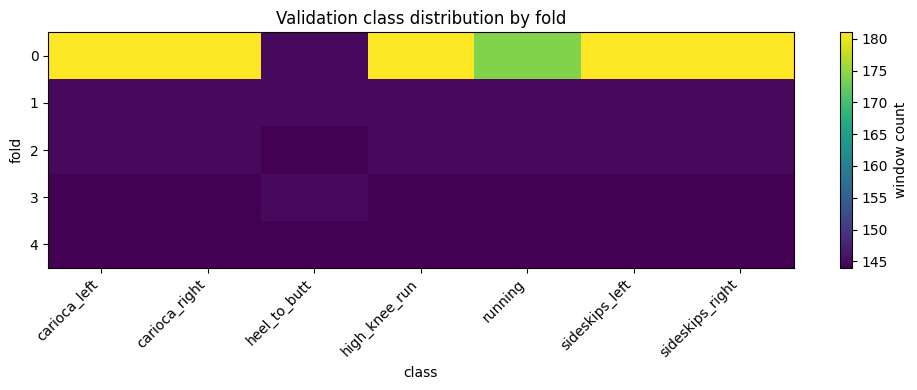

In [16]:
fold_class_rows = []

for fold in folds:
    fold_id = fold["fold_id"]
    val_idx = fold["val_idx"]
    labels_val = y_raw[val_idx]

    counts = pd.Series(labels_val).value_counts()

    for label, count in counts.items():
        fold_class_rows.append({
            "fold": fold_id,
            "label": label,
            "count": count,
        })

fold_class_df = pd.DataFrame(fold_class_rows)

fold_class_pivot = (
    fold_class_df
    .pivot(index="fold", columns="label", values="count")
    .fillna(0)
    .astype(int)
)

display(fold_class_pivot)

plt.figure(figsize=(10, 4))
plt.imshow(fold_class_pivot.values, aspect="auto")
plt.colorbar(label="window count")
plt.xticks(range(len(fold_class_pivot.columns)), fold_class_pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(fold_class_pivot.index)), fold_class_pivot.index)
plt.title("Validation class distribution by fold")
plt.xlabel("class")
plt.ylabel("fold")
plt.tight_layout()
plt.show()

Было проверено распределение классов в validation-части каждого fold. Во всех folds присутствуют все 7 классов, значит каждый fold можно использовать для оценки многоклассовой классификации. Fold 0 получился крупнее и немного менее равномерным, потому что `participant_12` и `participant_12_2` объединены в одну группу и попали в validation вместе, а также туда попал участник с укороченными записями. Это не ошибка, а следствие корректного group-wise split.

## 14. Сохраняем 5 фолдов и окна

In [17]:
meta_path = OUT_DIR / f"sensor{SENSOR_IDX}_1s_overlap75_window_meta.csv"
labels_path = OUT_DIR / f"sensor{SENSOR_IDX}_1s_overlap75_label_mapping.json"
all_windows_path = OUT_DIR / f"sensor{SENSOR_IDX}_1s_overlap75_all_windows.npz"

# Save full window dataset without split.
np.savez_compressed(
    all_windows_path,
    X=X,
    y=y,
    y_raw=y_raw,
    subjects=subjects,
    groups=groups,
    files=files,
    starts=starts,
)

window_meta_with_groups = window_meta.copy()
window_meta_with_groups["group_id"] = groups
window_meta_with_groups["y"] = y
window_meta_with_groups.to_csv(meta_path, index=False)

label_to_id_clean = {str(k): int(v) for k, v in label_to_id.items()}
id_to_label_clean = {str(k): str(v) for k, v in id_to_label.items()}

with open(labels_path, "w") as f:
    json.dump(
        {
            "label_to_id": label_to_id_clean,
            "id_to_label": id_to_label_clean,
        },
        f,
        indent=2,
    )

print("saved common files:")
print(" ", all_windows_path)
print(" ", meta_path)
print(" ", labels_path)

# Save each fold separately.
for fold in folds:
    fold_id = fold["fold_id"]
    train_idx = fold["train_idx"]
    val_idx = fold["val_idx"]

    X_train_raw = X[train_idx]
    X_val_raw = X[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    subjects_train = subjects[train_idx]
    subjects_val = subjects[val_idx]

    groups_train = groups[train_idx]
    groups_val = groups[val_idx]

    assert set(groups_train).isdisjoint(set(groups_val))

    # Fold-wise normalization: fit only on train of the current fold.
    mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
    std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-6

    X_train_norm = ((X_train_raw - mean) / std).astype(np.float32)
    X_val_norm = ((X_val_raw - mean) / std).astype(np.float32)

    npz_path = OUT_DIR / f"sensor{SENSOR_IDX}_1s_overlap75_fold{fold_id}.npz"

    np.savez_compressed(
        npz_path,
        X=X,
        y=y,
        y_raw=y_raw,
        subjects=subjects,
        groups=groups,
        files=files,
        starts=starts,

        fold_id=np.array(fold_id),
        train_idx=train_idx,
        val_idx=val_idx,

        X_train=X_train_norm,
        X_val=X_val_norm,
        y_train=y_train,
        y_val=y_val,
        subjects_train=subjects_train,
        subjects_val=subjects_val,
        groups_train=groups_train,
        groups_val=groups_val,

        mean=mean,
        std=std,
    )

    print(f"\nfold {fold_id}")
    print(" saved:", npz_path)
    print(" train windows:", len(train_idx))
    print(" val windows:  ", len(val_idx))
    print(" train subjects:", sorted(set(subjects_train)))
    print(" val subjects:  ", sorted(set(subjects_val)))
    print(" train groups:", sorted(set(groups_train)))
    print(" val groups:  ", sorted(set(groups_val)))
    print(" group leakage check:", set(groups_train).isdisjoint(set(groups_val)))

saved common files:
  /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/sensor0_1s_overlap75_all_windows.npz
  /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/sensor0_1s_overlap75_window_meta.csv
  /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/sensor0_1s_overlap75_label_mapping.json

fold 0
 saved: /Users/arsenij/Desktop/kurs-ml-ssl/data/processed/sensor0_1s_overlap75_fold0.npz
 train windows: 4046
 val windows:   1224
 train subjects: [np.str_('participant_1'), np.str_('participant_10'), np.str_('participant_11'), np.str_('participant_13'), np.str_('participant_14'), np.str_('participant_15'), np.str_('participant_17'), np.str_('participant_18'), np.str_('participant_19'), np.str_('participant_2'), np.str_('participant_3'), np.str_('participant_5'), np.str_('participant_6'), np.str_('participant_7'), np.str_('participant_8'), np.str_('participant_9')]
 val subjects:   [np.str_('participant_12'), np.str_('participant_12_2'), np.str_('participant_16'), np.str_('participant_20'), n

## 15. Проверка

In [18]:
for fold_id in range(N_SPLITS):
    fold_path = OUT_DIR / f"sensor{SENSOR_IDX}_1s_overlap75_fold{fold_id}.npz"
    assert fold_path.exists(), f"Missing: {fold_path}"

    loaded = np.load(fold_path, allow_pickle=True)

    print(f"\nfold {fold_id}")
    print(" keys:", loaded.files)
    print(" X_train:", loaded["X_train"].shape)
    print(" X_val:  ", loaded["X_val"].shape)
    print(" y_train:", loaded["y_train"].shape)
    print(" y_val:  ", loaded["y_val"].shape)

    groups_train_loaded = loaded["groups_train"].astype(str)
    groups_val_loaded = loaded["groups_val"].astype(str)

    leakage_ok = set(groups_train_loaded).isdisjoint(set(groups_val_loaded))
    print(" group leakage check:", leakage_ok)
    assert leakage_ok

print("\nAll folds verified.")


fold 0
 keys: ['X', 'y', 'y_raw', 'subjects', 'groups', 'files', 'starts', 'fold_id', 'train_idx', 'val_idx', 'X_train', 'X_val', 'y_train', 'y_val', 'subjects_train', 'subjects_val', 'groups_train', 'groups_val', 'mean', 'std']
 X_train: (4046, 6, 52)
 X_val:   (1224, 6, 52)
 y_train: (4046,)
 y_val:   (1224,)
 group leakage check: True

fold 1
 keys: ['X', 'y', 'y_raw', 'subjects', 'groups', 'files', 'starts', 'fold_id', 'train_idx', 'val_idx', 'X_train', 'X_val', 'y_train', 'y_val', 'subjects_train', 'subjects_val', 'groups_train', 'groups_val', 'mean', 'std']
 X_train: (4255, 6, 52)
 X_val:   (1015, 6, 52)
 y_train: (4255,)
 y_val:   (1015,)
 group leakage check: True

fold 2
 keys: ['X', 'y', 'y_raw', 'subjects', 'groups', 'files', 'starts', 'fold_id', 'train_idx', 'val_idx', 'X_train', 'X_val', 'y_train', 'y_val', 'subjects_train', 'subjects_val', 'groups_train', 'groups_val', 'mean', 'std']
 X_train: (4256, 6, 52)
 X_val:   (1014, 6, 52)
 y_train: (4256,)
 y_val:   (1014,)
 gro

# Общий вывод

Во втором ноутбуке исходные JSON-файлы были преобразованы в готовый ML-датасет для обучения моделей. Для каждого файла использовался один фиксированный сенсор `sensor_idx = 0`, из которого были извлечены 6 каналов IMU-сигнала: `acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`.

Сигналы были нарезаны методом sliding window с параметрами `WINDOW_SIZE = 52`, `OVERLAP = 0.75`, `STRIDE = 13`. Так как частота дискретизации составляет примерно 52.6 Hz, одно окно соответствует примерно 1 секунде сигнала. В результате был получен тензор:

`X.shape = (5270, 6, 52)`

То есть сформировано 5270 окон, каждое содержит 6 каналов и 52 временных отсчёта. Такая форма подходит для 1D-CNN в PyTorch.

Классы были закодированы в числовые id от 0 до 6. После нарезки окон классы остались достаточно сбалансированными, хотя появился небольшой дисбаланс из-за различной длины отдельных записей. Также было замечено, что некоторые участники, например `participant_4`, дают меньше окон по отдельным классам.

Для корректной оценки был создан `group_id`. Папки `participant_12` и `participant_12_2` были объединены в одну группу, чтобы избежать возможной утечки между train и validation. В результате получилось 21 `subject_id`, но 20 `group_id`.

Разбиение было выполнено с помощью `GroupKFold(n_splits=5)` по `group_id`. Для каждого fold проверено, что train и validation не пересекаются по группам. Это делает оценку subject-wise: модель проверяется на участниках, которых не видела во время обучения.

Нормализация выполнялась отдельно внутри каждого fold: `mean` и `std` считались только по `X_train`, а `X_val` нормализовался train-статистиками. Это исключает leakage через нормализацию.

В результате были сохранены файлы:

`sensor0_1s_overlap75_all_windows.npz`  
`sensor0_1s_overlap75_fold0.npz`  
`sensor0_1s_overlap75_fold1.npz`  
`sensor0_1s_overlap75_fold2.npz`  
`sensor0_1s_overlap75_fold3.npz`  
`sensor0_1s_overlap75_fold4.npz`  
`sensor0_1s_overlap75_window_meta.csv`  
`sensor0_1s_overlap75_label_mapping.json`

Итог: после ноутбука 02 данные полностью подготовлены для обучения. Получен тензор окон `X ∈ R^{5270 × 6 × 52}`, создано корректное 5-fold group-wise разбиение без data leakage, выполнена fold-wise нормализация и сохранены файлы для supervised baseline и SSL-экспериментов в ноутбуке 03.